<a href="https://colab.research.google.com/github/MrChelas/data-analytics-project-100/blob/main/charts_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Шаг 1. Подключаем библиотеки и первичные df

In [142]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from dotenv import load_dotenv
import os

## Создаем датафреймы из гугл таблиц

In [143]:
df_reg = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vT6rMyy3TfzrEheBOwlgts_SHTc67b_a8NsuSsfVnH6nI8x9zb9vt11gbMk1fWn4j3jvBxq9yqzPdhN/pub?gid=63066832&single=true&output=csv')

In [145]:
df_vis = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTC3r0B_geUBpk7soZCc03xDVzUBGMS__ZxPocgPQPmQ3guoVx9sXmNWwL2_vBHIFHVR_GDr4qlL5dH/pub?gid=1866591177&single=true&output=csv')

## Сводка общей информации по датафреймам

In [146]:
df_reg.describe()

,user_id
count,1.000000e+03
mean,4.488623e+06
std,2.620568e+06
min,2.236800e+04
25%,2.235489e+06
50%,4.473044e+06
75%,6.779707e+06
max,8.881772e+06


In [ ]:
df_vis.describe()

In [ ]:
#просмотр текущих переменных. Удалить можно через del (имя)
%whos

# Шаг 2. Подключение по API

In [147]:
load_dotenv()  # загружаются переменные из файла

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

In [148]:
#r_visits = requests.get('https://data-charts-api.hexlet.app/visits?begin=2023-03-01&end=2023-09-01')
r_visits = requests.get(f'{API_URL}/visits?begin={DATE_BEGIN}&end={DATE_END}')

In [149]:
#r_regs = requests.get('https://data-charts-api.hexlet.app/registrations?begin=2023-03-01&end=2023-09-01')
r_regs = requests.get(f'{API_URL}/registrations?begin={DATE_BEGIN}&end={DATE_END}')

In [150]:
df_api_visits = pd.DataFrame(r_visits.json())
df_api_regs = pd.DataFrame(r_regs.json())

# Шаг 3. Расчет метрик

### Подготовка датафрейма визитов

Удаляем время из даты

In [151]:
df_api_visits['datetime'] = pd.to_datetime(df_api_visits['datetime'])
df_api_visits['datetime'] = df_api_visits['datetime'].dt.date

Удаляем ботов из датафрейма с регистрациями

In [152]:
mask = df_api_visits['platform'] == 'bot'
df_api_visits = df_api_visits[~mask]
df_api_visits.head()

,visit_id,platform,user_agent,datetime
0,59c69c6f-81b3-4e63-b1b3-00a950cf9feb,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-17
1,a82c5ae1-3d3b-485e-a483-df963c5e0e7a,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-21
2,a82c5ae1-3d3b-485e-a483-df963c5e0e7a,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-18
3,87525d18-3dce-4d81-8fa8-47d900c70a90,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-07-21
4,87525d18-3dce-4d81-8fa8-47d900c70a90,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-07-20


Оставляем последний визит каждого пользователя, если их было больше 1

In [153]:
df_api_visits.sort_values(by=['visit_id', 'datetime'], inplace=True)
df_api_visits.drop_duplicates(subset='visit_id', keep='last', inplace=True)

Группируем по дате и платформе

In [154]:
df_visits_grouped = df_api_visits[['datetime', 'platform']].groupby(['datetime', 'platform']).agg(visits = ('platform', 'count')).reset_index()
df_visits_grouped.rename(columns={'datetime': 'date_group'}, inplace=True)
df_visits_grouped.head()

,date_group,platform,visits
0,2023-03-01,android,75
1,2023-03-01,ios,22
2,2023-03-01,web,279
3,2023-03-02,android,67
4,2023-03-02,ios,31


### Подготовка датафрейма с регистрациями

In [155]:
df_api_regs['datetime'] = pd.to_datetime(df_api_regs['datetime'])
df_api_regs['datetime'] = df_api_regs['datetime'].dt.date

In [156]:
df_regs_grouped = df_api_regs[['datetime', 'platform']].groupby(['datetime', 'platform']).agg(registrations = ('platform', 'count')).reset_index()
df_regs_grouped.rename(columns={'datetime': 'date_group'}, inplace=True)
df_regs_grouped

,date_group,platform,registrations
0,2023-03-01,android,61
1,2023-03-01,ios,18
2,2023-03-01,web,8
3,2023-03-02,android,59
4,2023-03-02,ios,24
...,...,...,...
547,2023-08-30,ios,40
548,2023-08-30,web,34
549,2023-08-31,android,42
550,2023-08-31,ios,36


### Объединение

In [157]:
df_joined = pd.merge(df_visits_grouped, df_regs_grouped, on=['date_group', 'platform'] ,how = 'left')

### Расчет конверсии

In [187]:
df_joined['conversion'] = (df_joined['registrations'] / df_joined['visits'] * 100.00)
df_joined.head()

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355


### Сохранение в json

In [188]:
df_joined.to_json('conversion.json', force_ascii=False)

# Шаг 4. Добавляем рекламы

### Загрузка csv  с данными о рекламных кампаниях, подготовка данных

In [160]:
#df_ads = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vT6RhvjENpQIKjGraRn24hPtM2REf8sYqvGh6pPCp3rwSfMagyiRSiUeZMugZWhimruBdoQzNeCAfEX/pub?gid=1700660919&single=true&output=csv')
df_ads = pd.read_csv('./ads.csv')

In [161]:
df_ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          159 non-null    object
 1   utm_source    159 non-null    object
 2   utm_medium    159 non-null    object
 3   utm_campaign  159 non-null    object
 4   cost          159 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 6.3+ KB


In [162]:
df_ads['date'] = pd.to_datetime(df_ads['date'])
df_ads['date'] = df_ads['date'].dt.date
df_ads.head()

,date,utm_source,utm_medium,utm_campaign,cost
0,2023-03-01,google,cpc,advanced_algorithms_series,212
1,2023-03-02,google,cpc,advanced_algorithms_series,252
2,2023-03-03,google,cpc,advanced_algorithms_series,202
3,2023-03-04,google,cpc,advanced_algorithms_series,223
4,2023-03-05,google,cpc,advanced_algorithms_series,265


### Объединяем конверсии и рекламы

In [163]:
df_ads_joined = pd.merge(df_joined, df_ads, left_on='date_group', right_on='date', how='left')

In [164]:
#Оставляем поля, указанные в требованиях шага 4 удаляем строки с nan в utm_campaign
df_ads_joined = df_ads_joined[df_ads_joined['utm_campaign'].notna()]
df_ads_joined = df_ads_joined[['date_group', 'visits','registrations','cost', 'utm_campaign']]
df_ads_joined.head()

,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,75,61,212.0,advanced_algorithms_series
1,2023-03-01,22,18,212.0,advanced_algorithms_series
2,2023-03-01,279,8,212.0,advanced_algorithms_series
3,2023-03-02,67,59,252.0,advanced_algorithms_series
4,2023-03-02,31,24,252.0,advanced_algorithms_series


### Сохраняем в json

In [165]:
#Объединенный файл реклам и конверсий
df_ads_joined.to_json('ads.json')

# Шаг 5. Визуализации

In [166]:
#Для визуализаций будем использовать charts
charts = df_joined
charts['date_group'] = pd.to_datetime(charts['date_group']).dt.date

In [167]:
#создаем папку для сохранения визуализаций
charts_path = "./charts"
os.makedirs(charts_path, exist_ok=True)

### Итоговые визиты

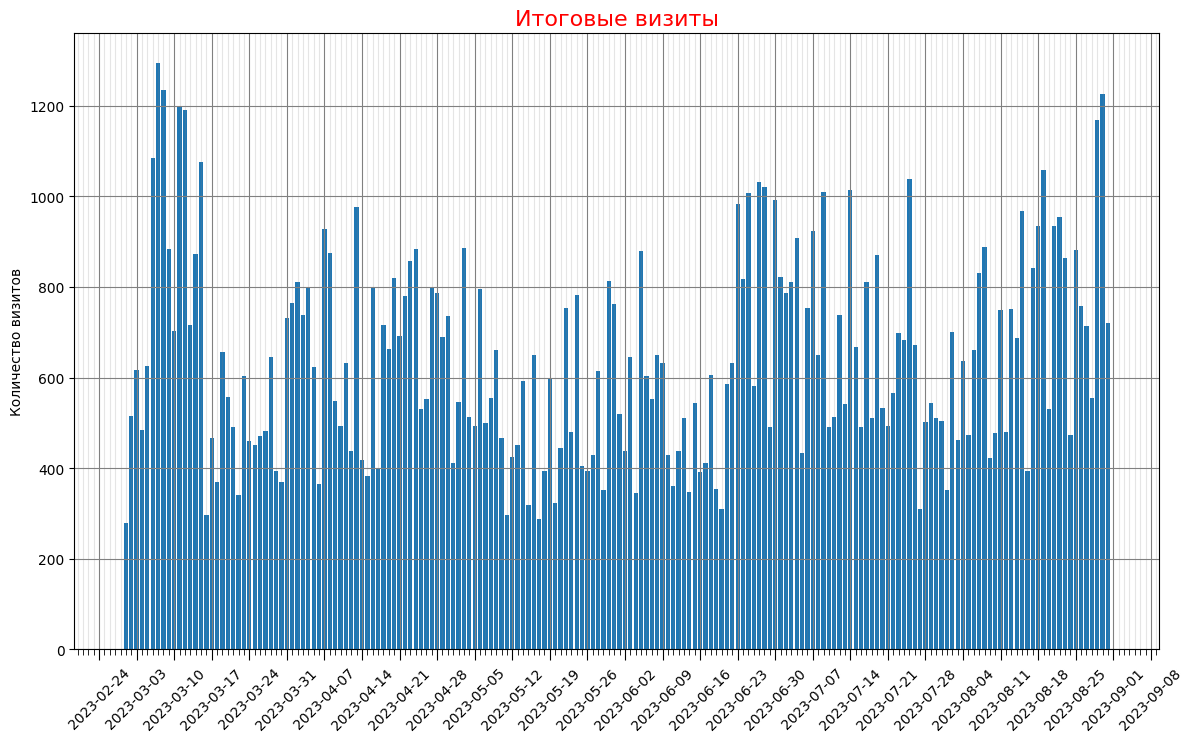

In [168]:
fig, ax = plt.subplots(figsize=(14,8))

ax.bar(charts['date_group'], charts['visits'])
ax.set_title('Итоговые визиты', fontsize=16, color='red')
ax.set_ylabel('Количество визитов', fontsize=10)
#ax.set_xlim(pd.to_datetime('2023-02-28'), pd.to_datetime('2023-09-01'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/total_visits.png', bbox_inches='tight')
plt.show()

### Итоговые визиты в разрезе платформ (web, Android, ios)

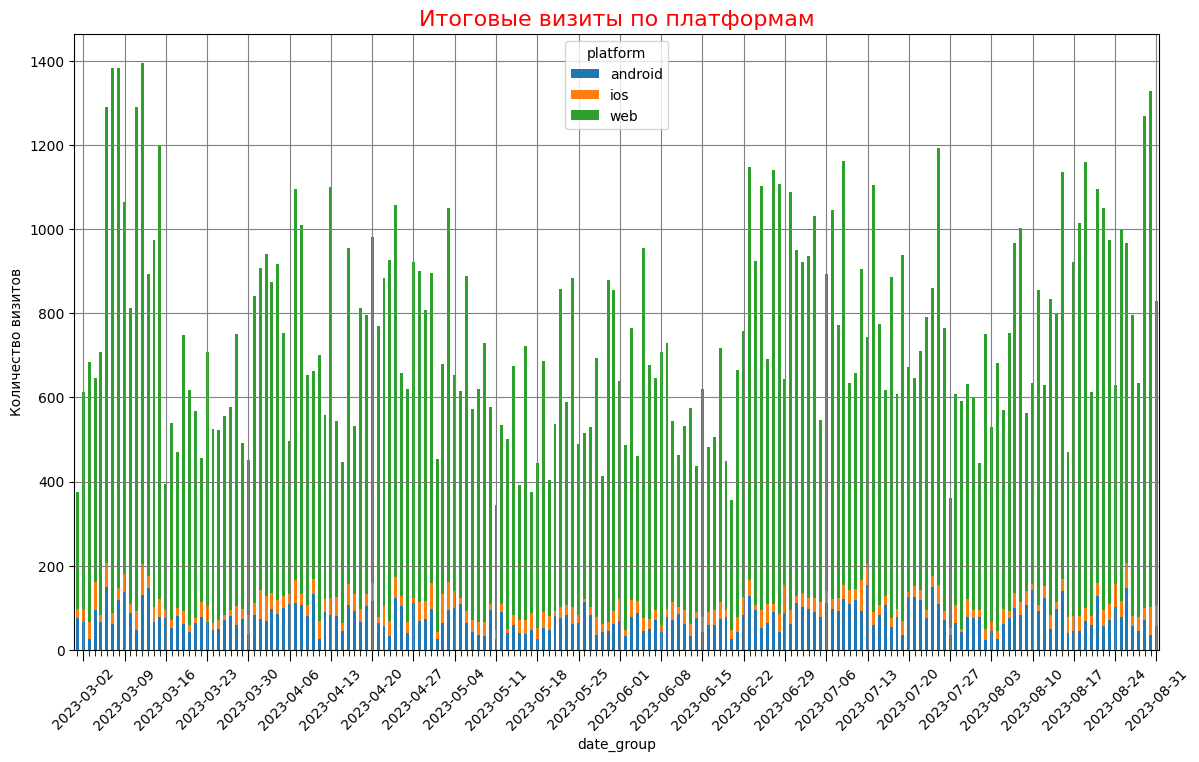

In [169]:
vis_by_platform = charts.pivot_table(index='date_group', columns='platform', values='visits')

fig, ax = plt.subplots(figsize=(14,8))

vis_by_platform.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Итоговые визиты по платформам', fontsize=16, color='red')
ax.set_ylabel('Количество визитов', fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.grid(which="major", color="gray")

plt.savefig('./charts/total_visit_by_platform.png', bbox_inches='tight')
plt.show()

### Итоговые регистрации

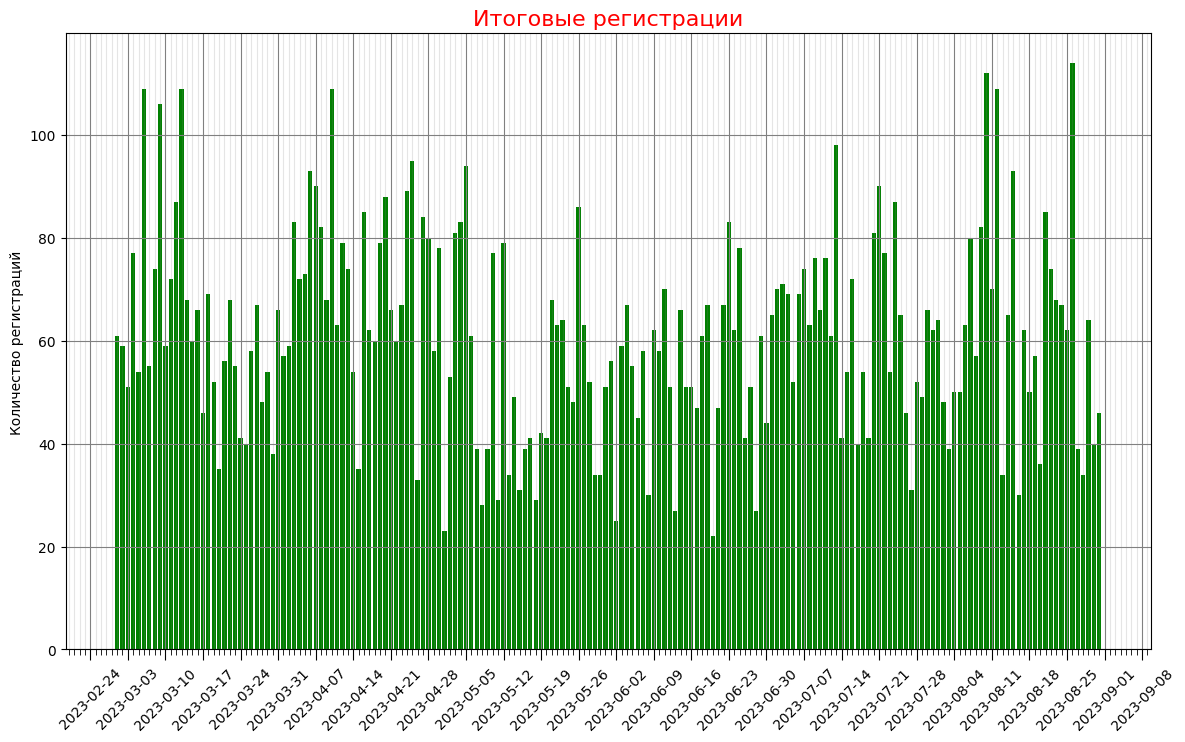

In [170]:
fig, ax = plt.subplots(figsize=(14,8))

ax.bar(charts['date_group'], charts['registrations'], color='g')
ax.set_title('Итоговые регистрации', fontsize=16, color='red')
ax.set_ylabel('Количество регистраций', fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/total_registrations.png', bbox_inches='tight')
plt.show()

### Итоговые регистрации с разбивкой по платформам

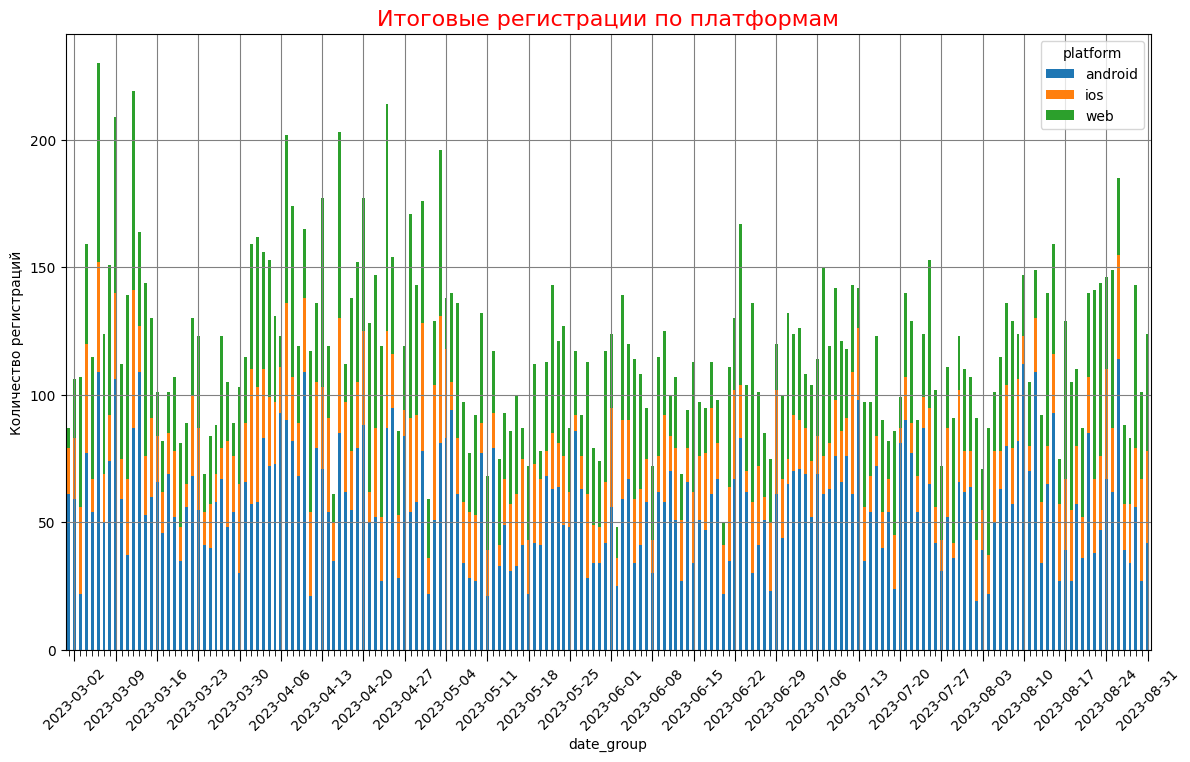

In [171]:
regs_by_platform = charts.pivot_table(index='date_group', columns='platform', values='registrations')

fig, ax = plt.subplots(figsize=(14,8))

regs_by_platform.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Итоговые регистрации по платформам', fontsize=16, color='red')
ax.set_ylabel('Количество регистраций', fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.grid(which="major", color="gray")

plt.savefig('./charts/total_registrations_by_platform.png', bbox_inches='tight')
plt.show()

### Итоговые конверсии

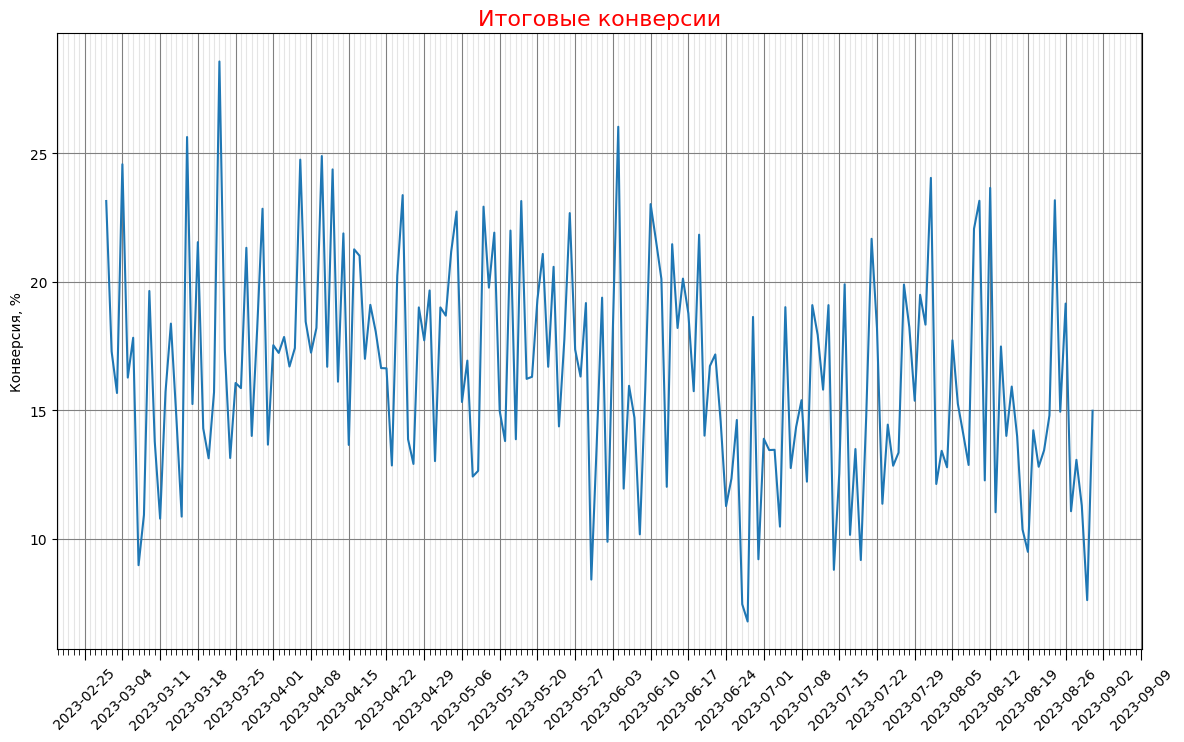

In [172]:
#Находим суммарные визиты и регистрации без разбивки по платформам
daily_summary = charts.groupby('date_group').agg(
    total_visits=('visits', 'sum'),
    total_registrations=('registrations', 'sum')
    ).reset_index()

#Добавляем конверсию без разбивки по платформам
daily_summary['conversion'] = (daily_summary['total_registrations'] / daily_summary['total_visits'] * 100.00).round(2)

fig, ax = plt.subplots(figsize=(14,8))

ax.plot(daily_summary['date_group'], daily_summary['conversion'])
ax.set_title('Итоговые конверсии', fontsize=16, color='red')
ax.set_ylabel('Конверсия, %', fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/conversions.png', bbox_inches='tight')
plt.show()

### Конверсия по платформам

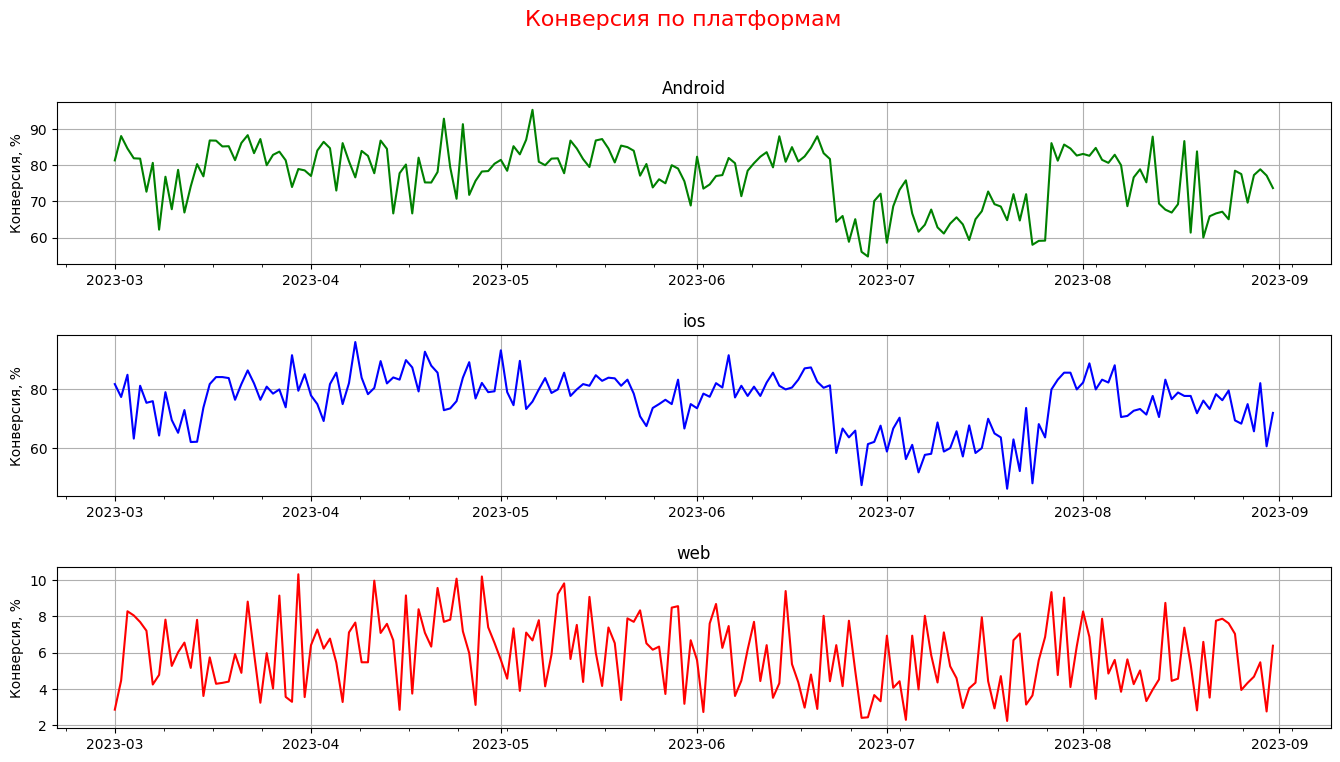

In [173]:
conv_by_platform = charts.pivot_table(index='date_group', columns='platform', values='conversion').reset_index()

fig, ax = plt.subplots(3, 1, figsize=(14,8))
fig.suptitle('Конверсия по платформам', fontsize=16, color='red')
plt.tight_layout(pad=3.0)

ax[0].plot(conv_by_platform['date_group'], conv_by_platform['android'], color='green')
ax[0].set_title('Android')
ax[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[0].set_ylabel('Конверсия, %')
ax[0].grid()

ax[1].plot(conv_by_platform['date_group'], conv_by_platform['ios'], color='blue')
ax[1].set_title('ios')
ax[1].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[1].set_ylabel('Конверсия, %')
ax[1].grid()


ax[2].plot(conv_by_platform['date_group'], conv_by_platform['web'], color='red')
ax[2].set_title('web')
ax[2].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[2].set_ylabel('Конверсия, %')
ax[2].grid()

plt.savefig('./charts/conversion_by_platform.png', bbox_inches='tight')
plt.show()

### Стоимости реклам

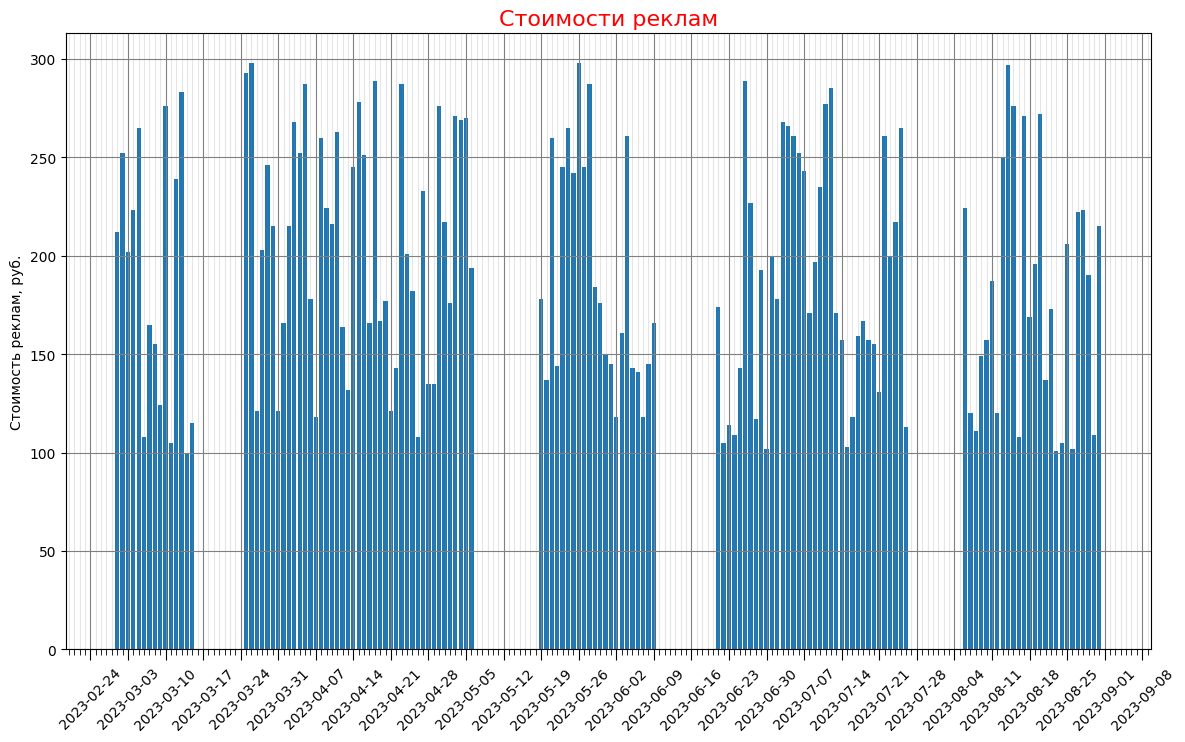

In [174]:
fig, ax = plt.subplots(figsize=(14,8))

ax.bar(df_ads_joined['date_group'], df_ads_joined['cost'])
ax.set_title('Стоимости реклам', fontsize=16, color='red')
ax.set_ylabel('Стоимость реклам, руб.', fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/ads_cost.png', bbox_inches='tight')
plt.show()

### Визиты и регистрации с выделением рекламных кампаний

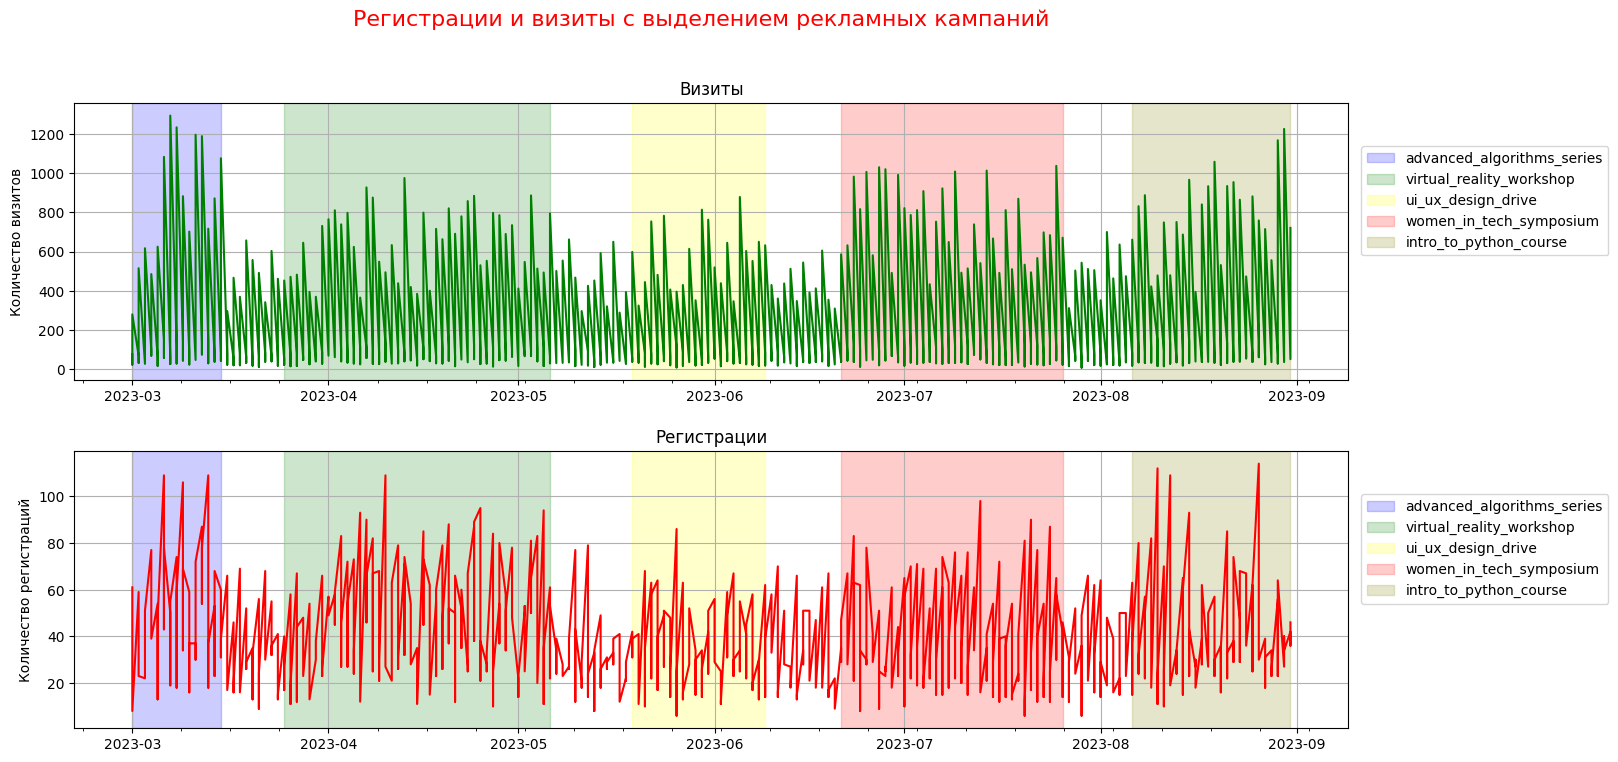

In [185]:
#Определяем даты старта (min) и окончания (max) для каждой рекламной кампании
ads_period_grouped = df_ads_joined[['date_group', 'utm_campaign']].groupby('utm_campaign').agg(min=('date_group', 'min'), max=('date_group', 'max')).sort_values(by='min')

fig, ax = plt.subplots(2, 1, figsize=(14,8))
fig.suptitle('Регистрации и визиты с выделением рекламных кампаний', fontsize=16, color='red')
plt.tight_layout(pad=3.0)

ax[0].plot(charts['date_group'], charts['visits'], color='green')
ax[1].plot(charts['date_group'], charts['registrations'], color='red')

colors = ['blue', 'green', 'yellow', 'red', 'olive']

for i, (campaign_name, row) in enumerate(ads_period_grouped.iterrows()):
    ax[0].axvspan(row['min'], row['max'], alpha=0.2, label=campaign_name, color=colors[i])
    ax[1].axvspan(row['min'], row['max'], alpha=0.2, label=campaign_name, color=colors[i])


ax[0].set_title('Визиты')
ax[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[0].set_ylabel('Количество визитов')
ax[0].legend(loc=(1.01, 0.45))
ax[0].grid()

ax[1].set_title('Регистрации')
ax[1].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[1].set_ylabel('Количество регистраций')
ax[1].legend(loc=(1.01, 0.45))
ax[1].grid()

plt.savefig('./charts/visits_regs_with_ads.png', bbox_inches='tight')
plt.show()

In [176]:
#добавление средней стоимости
ads_period_data = df_ads_joined.groupby('utm_campaign').agg(min=('date_group', 'min'), max=('date_group', 'max'), mean_cost=('cost', 'mean')).sort_values(by='min')
ads_period_data

,min,max,mean_cost
utm_campaign,,,
advanced_algorithms_series,2023-03-01,2023-03-15,188.266667
virtual_reality_workshop,2023-03-25,2023-05-06,210.023256
ui_ux_design_drive,2023-05-19,2023-06-09,191.318182
women_in_tech_symposium,2023-06-21,2023-07-26,188.333333
intro_to_python_course,2023-08-06,2023-08-31,180.384615
